# 04 - Monitoring SARIMA : compte-rendu d'un run d'entraînement

Ce notebook produit un **compte-rendu complet de monitoring** à partir des artefacts d'un run `train_sarima.py`.

**Entrée** : renseigne `TRAINING_DIR` (cellule suivante) avec le chemin vers le dossier du run, par exemple `../models/20260521T092314Z/`.

**Sections** :
1. Setup & configuration
2. Chargement des artefacts
3. Vue d'ensemble de la série temporelle
4. Ajustement in-sample (fitted vs réel)
5. Distribution des erreurs in-sample
6. Stabilité temporelle des erreurs
7. Calibration
8. Saisonnalité des erreurs
9. Prévisions récursives (dégradation par horizon)
10. Analyse des résidus du modèle final
11. Seuils de monitoring et synthèse

## 1. Setup & Configuration

In [32]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 0

# ── PARAMÈTRE D'ENTRÉE ──────────────────────────────────────────────────────
# Remplace par le chemin vers le dossier du run à analyser.
# Exemple : Path("../models/20260521T092314Z")
TRAINING_DIR = Path("../models/REMPLACE_PAR_LE_RUN_ID")
# ────────────────────────────────────────────────────────────────────────────

# Constantes
ROLLING_WINDOW = 30    # fenêtre (jours) pour rolling MAE / RMSE
_ALERT_FACTOR = 2.0    # seuil d'alerte = baseline × _ALERT_FACTOR
WARMUP_DAYS = 60       # premiers jours exclus des métriques et graphiques

TRAINING_DIR = TRAINING_DIR.resolve()

if not TRAINING_DIR.exists():
    try:
        metadata_path = "../models/sarima_metadata.json"
        with open(metadata_path, "r") as f:
            metadata = json.load(f)
        latest_run = metadata["latest_run_id"]
        TRAINING_DIR = Path(f"../models/{latest_run}")
    except Exception as e:
        raise FileNotFoundError(f"Dossier introuvable : {TRAINING_DIR}") from e

print(f"Dossier du run : {TRAINING_DIR}")

Dossier du run : ../models/20260521T101101Z


## 2. Chargement des artefacts du run

In [33]:
# ── Métadonnées JSON ─────────────────────────────────────────────────────────
run_id = TRAINING_DIR.name
json_path = TRAINING_DIR / f"sarima_run_{run_id}.json"

if not json_path.exists():
    raise FileNotFoundError(f"Fichier de métadonnées introuvable : {json_path}")

with json_path.open(encoding="utf-8") as fh:
    run_meta = json.load(fh)

HORIZONS = sorted(m["horizon"] for m in run_meta["models"])
meta_by_h = {m["horizon"]: m for m in run_meta["models"]}

# ── Modèles et scalers ────────────────────────────────────────────────────────
models = {}
scalers = {}

for h in HORIZONS:
    meta = meta_by_h[h]
    model_path = TRAINING_DIR / meta["artefacts"]["model"]
    scaler_path = TRAINING_DIR / meta["artefacts"]["scaler"]

    if not model_path.exists():
        raise FileNotFoundError(f"Modèle introuvable : {model_path}")
    if not scaler_path.exists():
        raise FileNotFoundError(f"Scaler introuvable : {scaler_path}")

    models[h] = joblib.load(model_path)
    scalers[h] = joblib.load(scaler_path)
    print(f"✓ Modèle  t+{h} : {model_path.name}")
    print(f"  Scaler  t+{h} : {scaler_path.name}")

# ── Reconstruction de la série réelle depuis le modèle chargé ────────────────
# Les SARIMAXResults conservent les données d'entraînement.
# On utilise l'horizon t+1 comme référence pour la série cible.
_ref_model = models[HORIZONS[0]]
_dates = _ref_model.model.data.dates
_endog = _ref_model.model.endog.flatten()
ts_train = pd.Series(_endog, index=_dates, name="consommation_mw")
ts_train.index = pd.DatetimeIndex(ts_train.index)

print(f"\nSérie cible reconstruite : {len(ts_train)} jours")
print(f"  [{ts_train.index.min().date()} → {ts_train.index.max().date()}]")

# ── Résumé du run ─────────────────────────────────────────────────────────────
m0 = meta_by_h[HORIZONS[0]]
print(f"\n{'='*55}")
print(f"Run ID      : {run_id}")
print(f"Entraîné    : {m0['trained_at']}")
print(f"Ordres      : SARIMA{tuple(m0['order'])} × {tuple(m0['seasonal_order'])}")
print(f"Features    : {m0['features']}")
print(f"Horizons    : {HORIZONS}")
print(f"{'='*55}")

✓ Modèle  t+1 : sarima_h1_20260521T101101Z.pkl
  Scaler  t+1 : scaler_h1_20260521T101101Z.pkl

Série cible reconstruite : 4748 jours
  [2012-01-02 → 2024-12-31]

Run ID      : 20260521T101101Z
Entraîné    : 2026-05-21T10:11:39.809305+00:00
Ordres      : SARIMA(2, 0, 1) × (2, 1, 0, 7)
Features    : ['temp_pc_01', 'temp_pc_02', 'temp_pc_03', 'production_mw_lag1']
Horizons    : [1]


## 3. Vue d'ensemble de la série temporelle

=== Statistiques de base ===


,consommation_mw
count,4748.0
mean,52745.6
std,10778.8
min,33032.3
25%,44609.4
50%,49377.1
75%,60545.2
max,93180.7


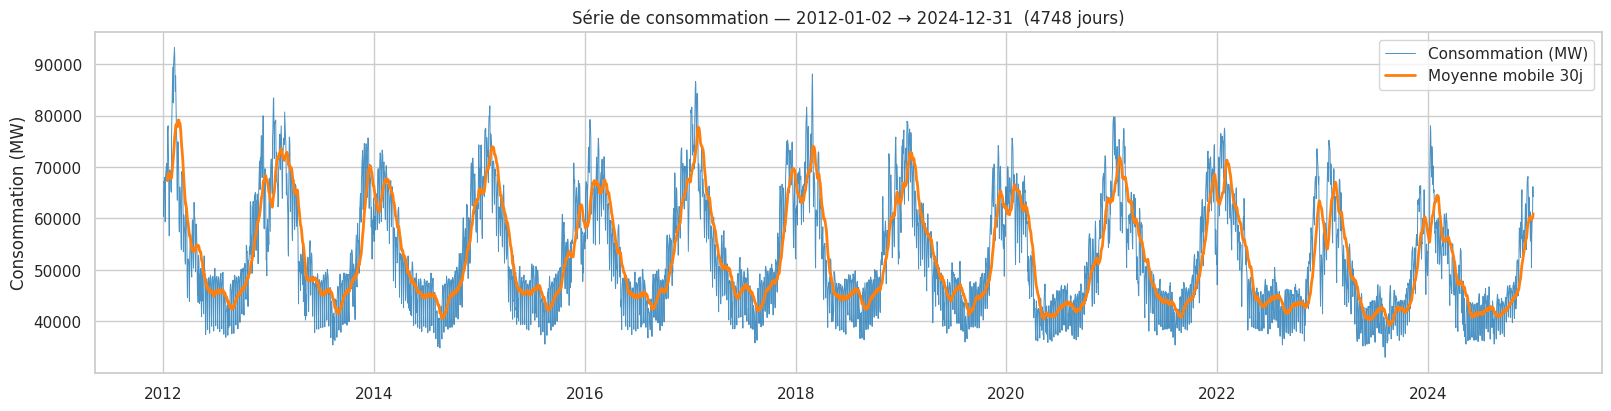

In [34]:
print("=== Statistiques de base ===")
stats_summary = ts_train.describe().rename("consommation_mw").round(1)
display(stats_summary.to_frame())

fig, ax = plt.subplots(figsize=(16, 4), constrained_layout=True)
ax.plot(ts_train.index, ts_train.values, linewidth=0.7, color="#1f77b4", alpha=0.8, label="Consommation (MW)")
rolling_mean = ts_train.rolling(30, min_periods=15).mean()
ax.plot(rolling_mean.index, rolling_mean.values, linewidth=2.0, color="#ff7f0e", label="Moyenne mobile 30j")
ax.set_title(f"Série de consommation — {ts_train.index.min().date()} → {ts_train.index.max().date()}  ({len(ts_train)} jours)")
ax.set_ylabel("Consommation (MW)")
ax.legend()
plt.show()

## 4. Ajustement in-sample (Fitted vs Réel)

Les valeurs ajustées sont les prédictions **one-step-ahead in-sample** du modèle SARIMAX.
Elles constituent la référence de performance sur les données d'entraînement.

Métriques in-sample :


,MAE (MW),RMSE (MW),MAPE (%),AIC,BIC,n jours
Horizon,,,,,,
t+1,1328.0,1899.6,2.618,84768.89,84833.5,4688


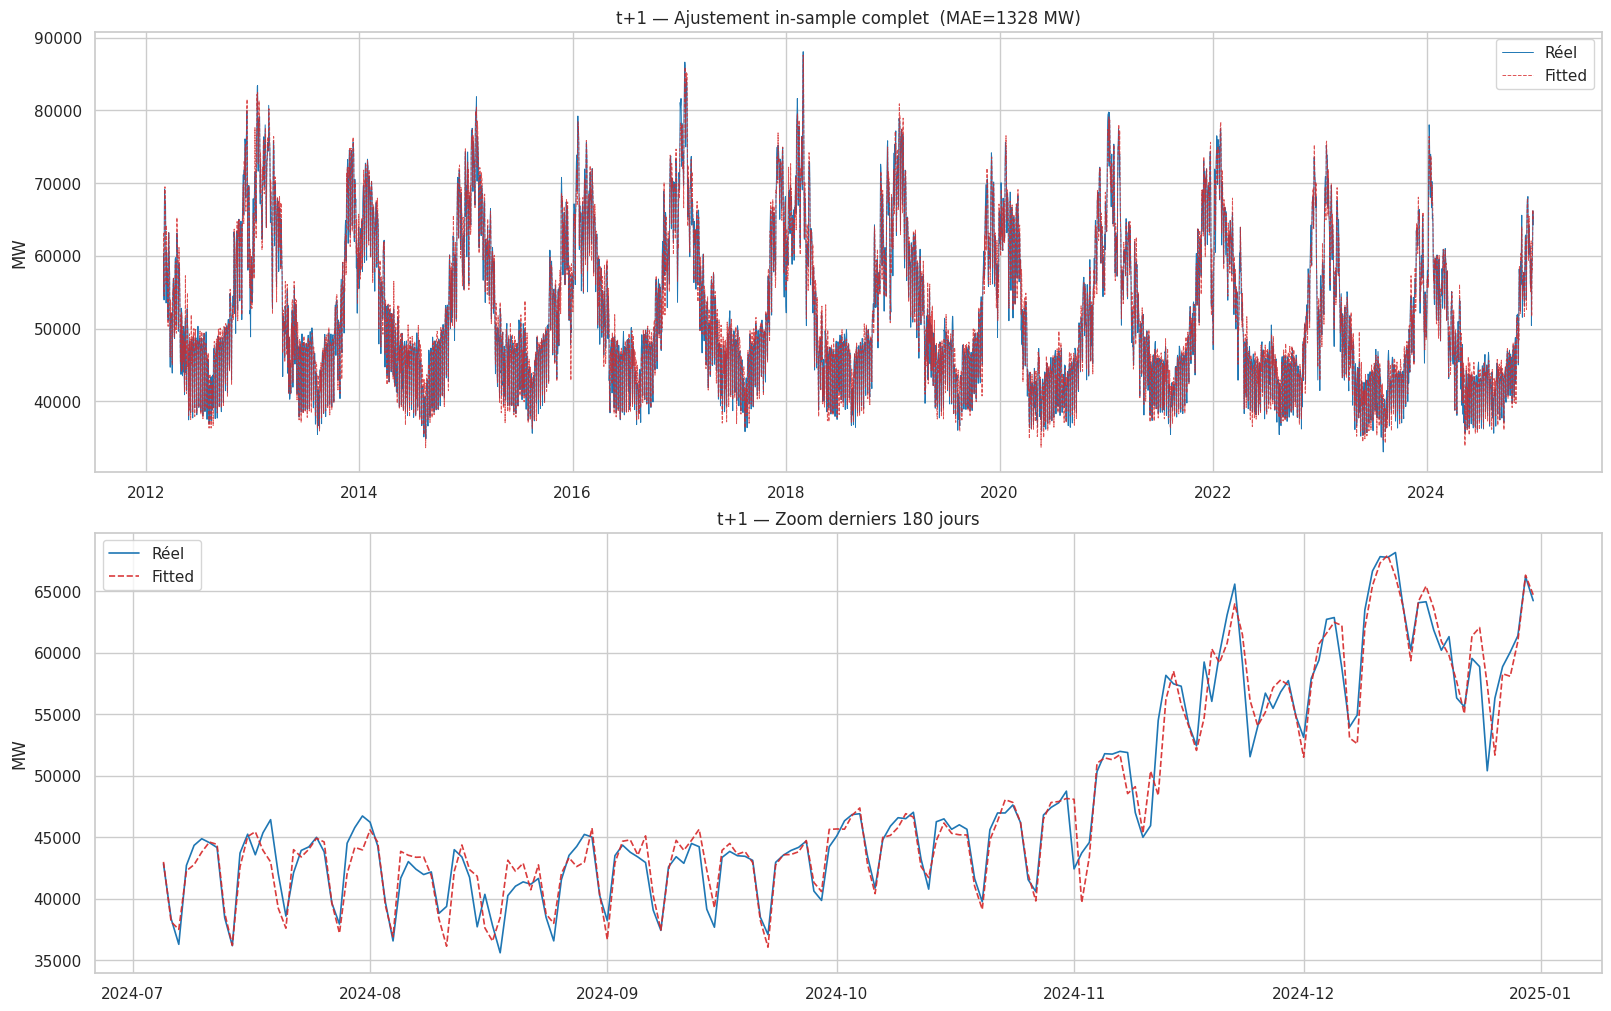

In [35]:
# Construire un DataFrame unifié fitted/actual pour tous les horizons
insample_by_h = {}

for h in HORIZONS:
    fitted = models[h].fittedvalues.dropna()
    fitted.index = pd.DatetimeIndex(fitted.index)
    actual = ts_train.reindex(fitted.index).dropna()
    common = actual.index.intersection(fitted.index)
    insample_by_h[h] = pd.DataFrame({
        "actual": actual.loc[common],
        "fitted": fitted.loc[common],
        "error": fitted.loc[common] - actual.loc[common],
        "abs_error": (fitted.loc[common] - actual.loc[common]).abs(),
    })

# Exclure les WARMUP_DAYS premiers jours (phase d'initialisation du modèle)
for h in HORIZONS:
    insample_by_h[h] = insample_by_h[h].iloc[WARMUP_DAYS:]

# Tableau de métriques in-sample
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

metrics_rows = []
for h in HORIZONS:
    df = insample_by_h[h]
    mae = mean_absolute_error(df["actual"], df["fitted"])
    rmse = float(np.sqrt(mean_squared_error(df["actual"], df["fitted"])))
    mape = mean_absolute_percentage_error(df["actual"], df["fitted"]) * 100
    gof = meta_by_h[h].get("goodness_of_fit", {})
    metrics_rows.append({
        "Horizon": f"t+{h}",
        "MAE (MW)": round(mae, 1),
        "RMSE (MW)": round(rmse, 1),
        "MAPE (%)": round(mape, 4),
        "AIC": gof.get("aic", float("nan")),
        "BIC": gof.get("bic", float("nan")),
        "n jours": len(df),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index("Horizon")
print("Métriques in-sample :")
display(metrics_df)

# Graphiques fitted vs réel (complet + zoom)
RECENT = 180
fig, axes = plt.subplots(len(HORIZONS) * 2, 1,
                          figsize=(16, 5 * len(HORIZONS) * 2),
                          constrained_layout=True)
ax_it = iter(axes)

for h in HORIZONS:
    df = insample_by_h[h]
    mae_val = metrics_rows[[r["Horizon"] for r in metrics_rows].index(f"t+{h}")]["MAE (MW)"]

    ax_full = next(ax_it)
    ax_full.plot(df.index, df["actual"], linewidth=0.7, color="#1f77b4", label="Réel")
    ax_full.plot(df.index, df["fitted"], linewidth=0.7, color="#d62728",
                 linestyle="--", alpha=0.8, label="Fitted")
    ax_full.set_title(f"t+{h} — Ajustement in-sample complet  (MAE={mae_val:.0f} MW)")
    ax_full.set_ylabel("MW")
    ax_full.legend()

    ax_zoom = next(ax_it)
    ax_zoom.plot(df.index[-RECENT:], df["actual"].iloc[-RECENT:],
                 linewidth=1.2, color="#1f77b4", label="Réel")
    ax_zoom.plot(df.index[-RECENT:], df["fitted"].iloc[-RECENT:],
                 linewidth=1.2, color="#d62728", linestyle="--", alpha=0.9, label="Fitted")
    ax_zoom.set_title(f"t+{h} — Zoom derniers {RECENT} jours")
    ax_zoom.set_ylabel("MW")
    ax_zoom.legend()

plt.show()

In [36]:
# Enrichissement des DataFrames avec colonnes calendaires
for h in HORIZONS:
    df = insample_by_h[h]
    df["month"] = df.index.month
    df["dow"] = df.index.dayofweek
    df["day_name"] = df.index.day_name()
    df["sq_error"] = df["error"] ** 2

## 5. Distribution des erreurs

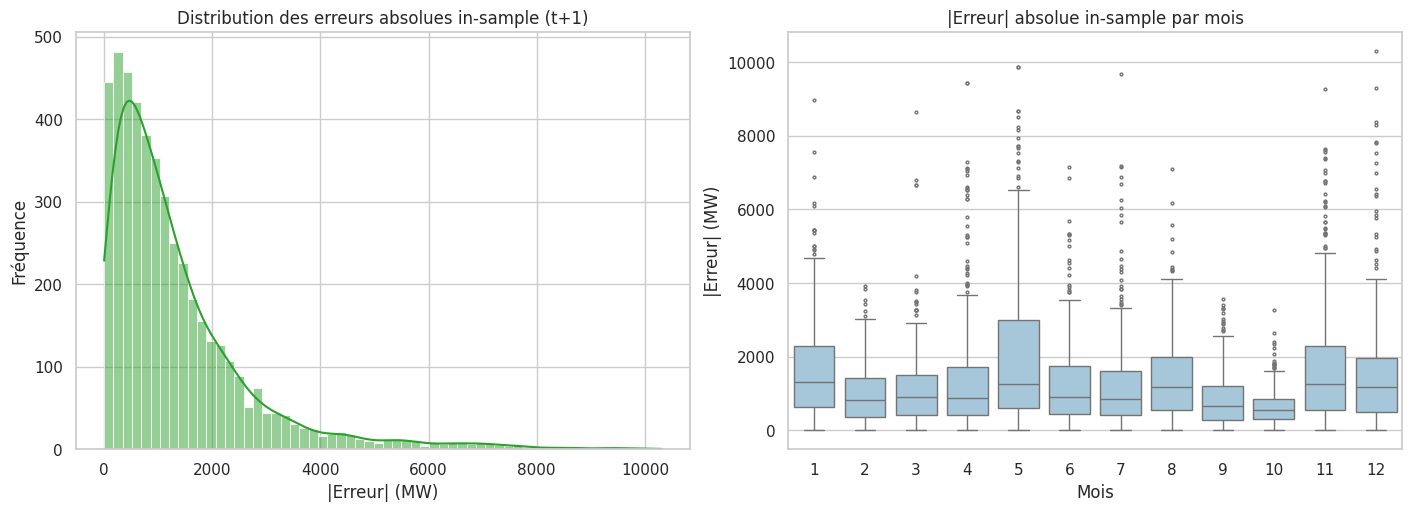

Statistiques des erreurs in-sample (t+1) :


,|Erreur| (MW)
count,4688.0
mean,1328.0
std,1358.4
min,0.5
25%,434.3
50%,933.8
75%,1729.3
max,10309.9


In [37]:
df1 = insample_by_h[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Histogramme des erreurs absolues
sns.histplot(df1["abs_error"], bins=60, kde=True, ax=axes[0], color="#2ca02c")
axes[0].set_title("Distribution des erreurs absolues in-sample (t+1)")
axes[0].set_xlabel("|Erreur| (MW)")
axes[0].set_ylabel("Fréquence")

# Erreurs par mois
sns.boxplot(data=df1.reset_index(names="date"), x="month", y="abs_error",
            ax=axes[1], color="#9ecae1", fliersize=2)
axes[1].set_title("|Erreur| absolue in-sample par mois")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("|Erreur| (MW)")

plt.show()

print("Statistiques des erreurs in-sample (t+1) :")
display(df1["abs_error"].describe().rename("|Erreur| (MW)").round(1).to_frame())

## 6. Stabilité temporelle des erreurs

Une dégradation progressive de la MAE/RMSE au fil du temps peut indiquer un changement structurel ou un besoin de ré-entraînement.

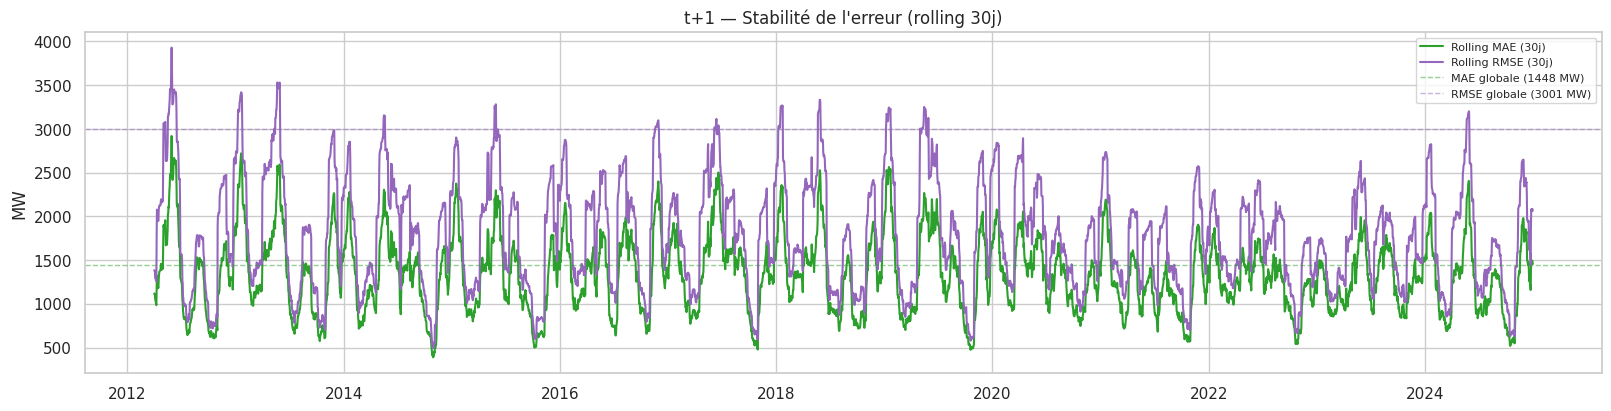

In [38]:
fig, axes = plt.subplots(len(HORIZONS), 1,
                          figsize=(16, 4 * len(HORIZONS)),
                          constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, h in zip(axes, HORIZONS):
    df = insample_by_h[h].sort_index()
    rolling_mae = df["abs_error"].rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW // 2).mean()
    rolling_rmse = np.sqrt(df["sq_error"].rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW // 2).mean())

    # Exclure la phase de chauffe de la fenêtre glissante
    rolling_mae = rolling_mae.iloc[ROLLING_WINDOW:]
    rolling_rmse = rolling_rmse.iloc[ROLLING_WINDOW:]

    # Baselines depuis les métadonnées
    m_meta = meta_by_h[h].get("insample_metrics", {})
    b_mae = m_meta.get("insample_MAE_MW")
    b_rmse = m_meta.get("insample_RMSE_MW")

    ax.plot(rolling_mae.index, rolling_mae, color="#2ca02c",
            label=f"Rolling MAE ({ROLLING_WINDOW}j)")
    ax.plot(rolling_rmse.index, rolling_rmse, color="#9467bd",
            label=f"Rolling RMSE ({ROLLING_WINDOW}j)")

    if b_mae:
        ax.axhline(b_mae, color="#2ca02c", linewidth=1.0, linestyle="--", alpha=0.5,
                   label=f"MAE globale ({b_mae:.0f} MW)")
    if b_rmse:
        ax.axhline(b_rmse, color="#9467bd", linewidth=1.0, linestyle="--", alpha=0.5,
                   label=f"RMSE globale ({b_rmse:.0f} MW)")

    ax.set_title(f"t+{h} — Stabilité de l'erreur (rolling {ROLLING_WINDOW}j)")
    ax.set_ylabel("MW")
    ax.legend(fontsize=8)

plt.show()

## 7. Calibration (Réel vs Prédit)

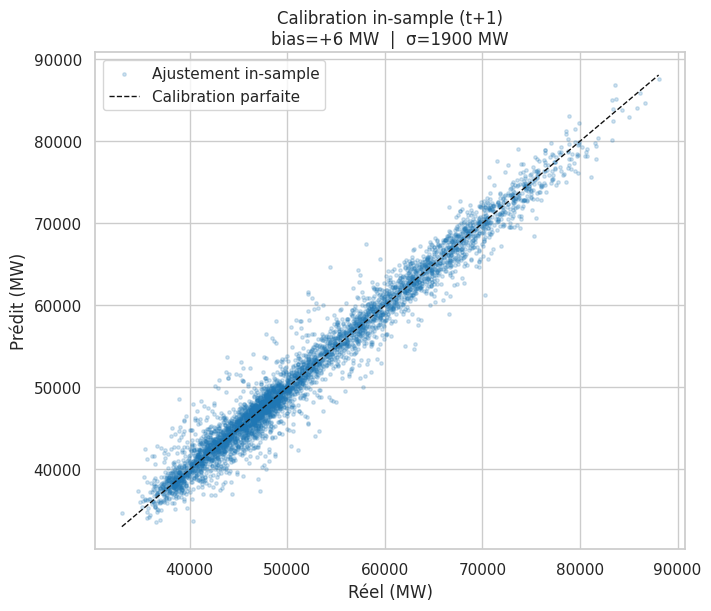

In [39]:
df1 = insample_by_h[1]

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

ax.scatter(df1["actual"], df1["fitted"], s=6, alpha=0.2, color="#1f77b4",
           label="Ajustement in-sample")

lo = min(df1["actual"].min(), df1["fitted"].min())
hi = max(df1["actual"].max(), df1["fitted"].max())
ax.plot([lo, hi], [lo, hi], color="#111111", linestyle="--", linewidth=1,
        label="Calibration parfaite")

bias = float(df1["error"].mean())
var = float(df1["error"].std())
ax.set_title(f"Calibration in-sample (t+1)\nbias={bias:+.0f} MW  |  σ={var:.0f} MW")
ax.set_xlabel("Réel (MW)")
ax.set_ylabel("Prédit (MW)")
ax.legend()

plt.show()

## 8. Saisonnalité des erreurs (mois × jour de semaine)

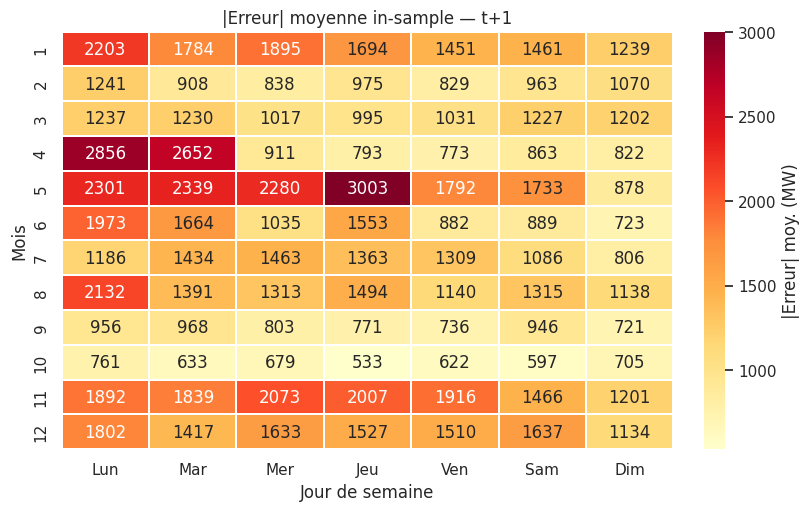

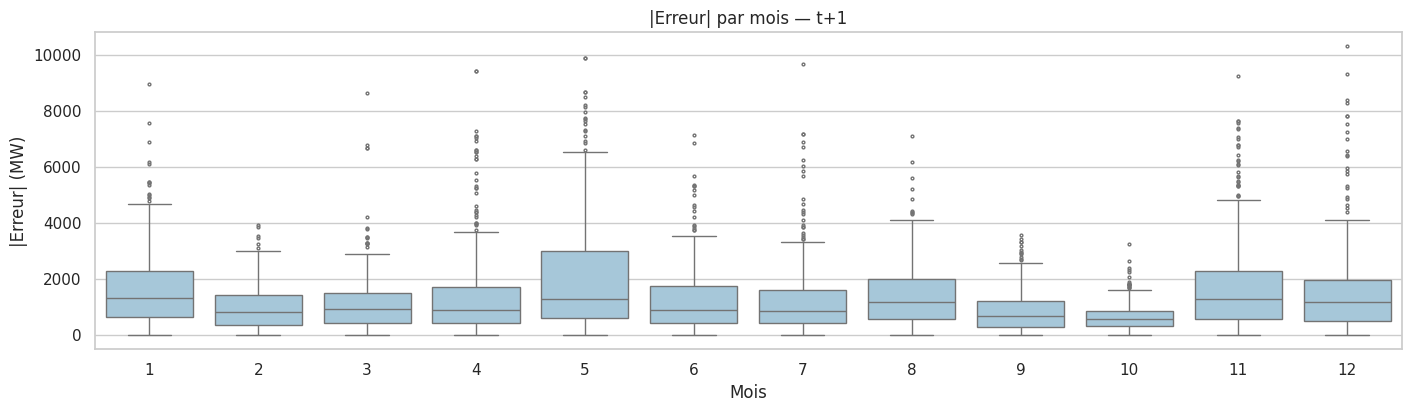

In [40]:
WEEKDAY_LABELS = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

fig, axes = plt.subplots(1, len(HORIZONS),
                          figsize=(8 * len(HORIZONS), 5),
                          constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, h in zip(axes, HORIZONS):
    df = insample_by_h[h]
    pivot = df.pivot_table(index="month", columns="dow",
                            values="abs_error", aggfunc="mean")
    pivot.columns = [WEEKDAY_LABELS[i] for i in pivot.columns]
    sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f", ax=ax,
                linewidths=0.3, cbar_kws={"label": "|Erreur| moy. (MW)"})
    ax.set_title(f"|Erreur| moyenne in-sample — t+{h}")
    ax.set_xlabel("Jour de semaine")
    ax.set_ylabel("Mois")

plt.show()

# Erreur mensuelle (boxplot)
fig, axes = plt.subplots(len(HORIZONS), 1,
                          figsize=(14, 4 * len(HORIZONS)),
                          constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, h in zip(axes, HORIZONS):
    df = insample_by_h[h]
    sns.boxplot(data=df.reset_index(), x="month", y="abs_error", ax=ax,
                color="#9ecae1", fliersize=2)
    ax.set_title(f"|Erreur| par mois — t+{h}")
    ax.set_xlabel("Mois")
    ax.set_ylabel("|Erreur| (MW)")

plt.show()

## 9. Prévisions récursives (dégradation par horizon)

Contrairement aux sections précédentes qui montrent l'ajustement **one-step-ahead in-sample**, cette section évalue la **dégradation des performances** lorsque le modèle est utilisé de façon récursive :

- À chaque point de départ *t*, on prédit *t+1* avec les données réelles jusqu'à *t*.
- La prédiction ŷ(*t+1*) alimente les termes AR pour prédire *t+2*, etc., jusqu'à l'horizon souhaité.
- L'erreur des composantes AR/SAR **s'accumule** à mesure que l'horizon grandit.
- Les variables exogènes futures (température PCA, production lag-1) sont supposées **connues** (borne optimiste).

Le graphique de dégradation révèle jusqu'à quel horizon le modèle reste utilisable.

In [41]:
# ── Paramètres ───────────────────────────────────────────────────────────────
MAX_HORIZON = 14   # horizon maximal (jours)
EVAL_STEP   = 14   # espacement entre les points de départ (jours)
EVAL_WINDOW = 365  # utilise les N derniers jours de la série d'entraînement
# ─────────────────────────────────────────────────────────────────────────────

model_h1 = models[1]
model_dates = pd.DatetimeIndex(model_h1.model.data.dates)
endog_arr   = model_h1.model.endog.flatten()
n           = len(endog_arr)

eval_start_i = max(0, n - EVAL_WINDOW - MAX_HORIZON)
eval_points  = list(range(eval_start_i, n - MAX_HORIZON, EVAL_STEP))

print(f"Points de départ : {len(eval_points)}")
print(f"Fenêtre d'évaluation : {model_dates[eval_start_i].date()}"
      f" → {model_dates[n - MAX_HORIZON - 1].date()}")
print("Calcul en cours…")

records = []
for start_i in eval_points:
    end_i = start_i + MAX_HORIZON
    if end_i >= n:
        break
    try:
        # predict(start, end, dynamic=True) :
        #   - utilise les valeurs réelles jusqu'à start-1 pour initialiser l'état
        #   - à partir de start, les prédictions précédentes alimentent les termes AR
        #   - les variables exogènes aux temps futurs viennent du dataset d'entraînement
        preds = model_h1.predict(
            start=start_i + 1,
            end=end_i,
            dynamic=True,
        )
        for h in range(1, MAX_HORIZON + 1):
            target_i = start_i + h
            if target_i >= n or h - 1 >= len(preds):
                break
            actual_val = float(endog_arr[target_i])
            pred_val   = float(preds.iloc[h - 1])
            records.append({
                "start_date": model_dates[start_i],
                "target_date": model_dates[target_i],
                "horizon": h,
                "actual": actual_val,
                "predicted": pred_val,
                "abs_error": abs(pred_val - actual_val),
                "error": pred_val - actual_val,
            })
    except Exception as e:
        print(f"  ⚠ Départ {model_dates[start_i].date()} : {e}")

recursive_df = pd.DataFrame(records)
print(f"Terminé — {len(recursive_df)} prédictions collectées "
      f"({len(eval_points)} départs × {MAX_HORIZON} horizons)")

Points de départ : 27
Fenêtre d'évaluation : 2023-12-19 → 2024-12-17
Calcul en cours…


Terminé — 378 prédictions collectées (27 départs × 14 horizons)


Métriques par horizon de prédiction récursive :


,MAE (MW),RMSE (MW),MAPE (%),n
h,,,,
1,1390.1,1801.4,2.885,27
2,1392.9,1954.0,2.913,27
3,1129.2,1608.8,2.185,27
4,1100.0,1457.7,2.476,27
5,1279.2,1701.3,2.905,27
6,2471.1,3340.9,5.053,27
7,1424.0,1851.6,2.845,27
8,1867.8,2762.3,3.909,27
9,1374.3,1878.8,2.772,27


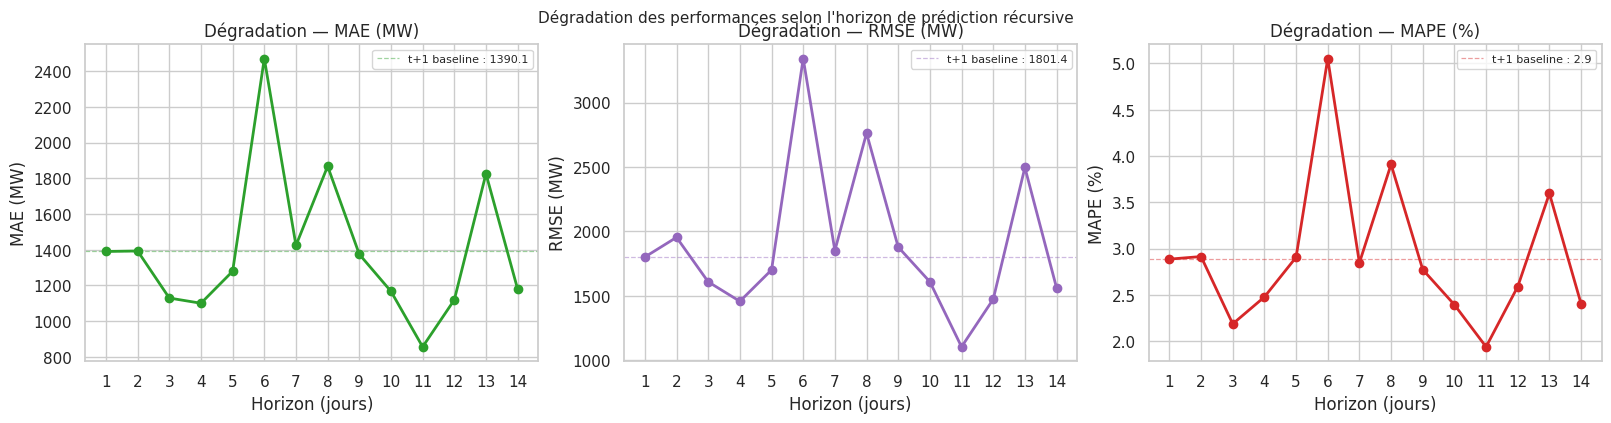

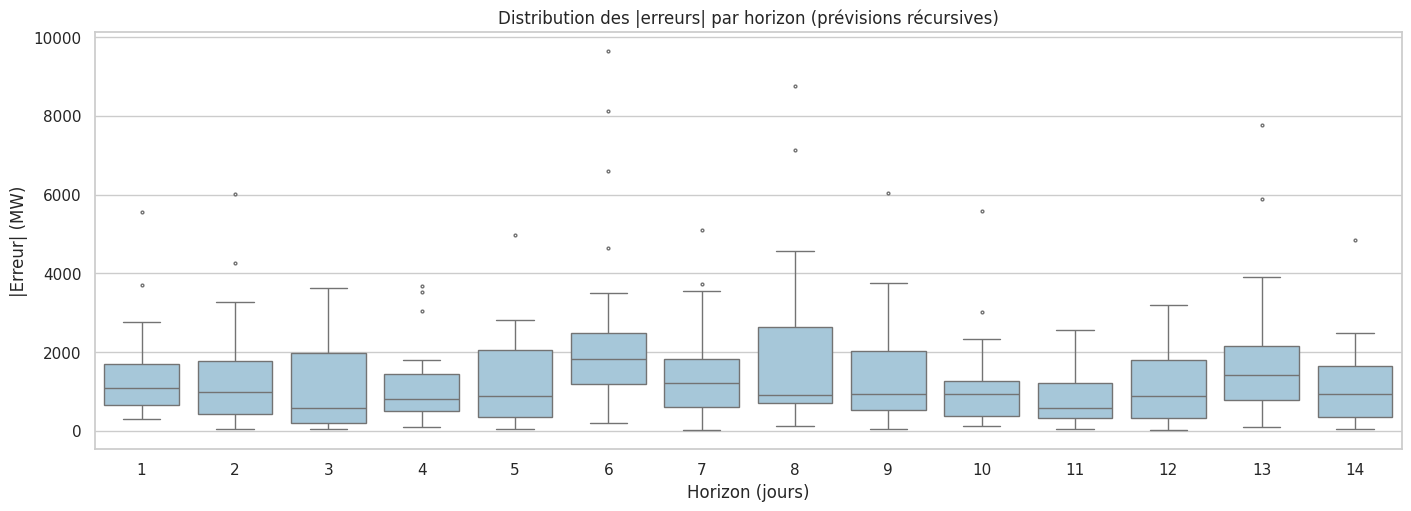

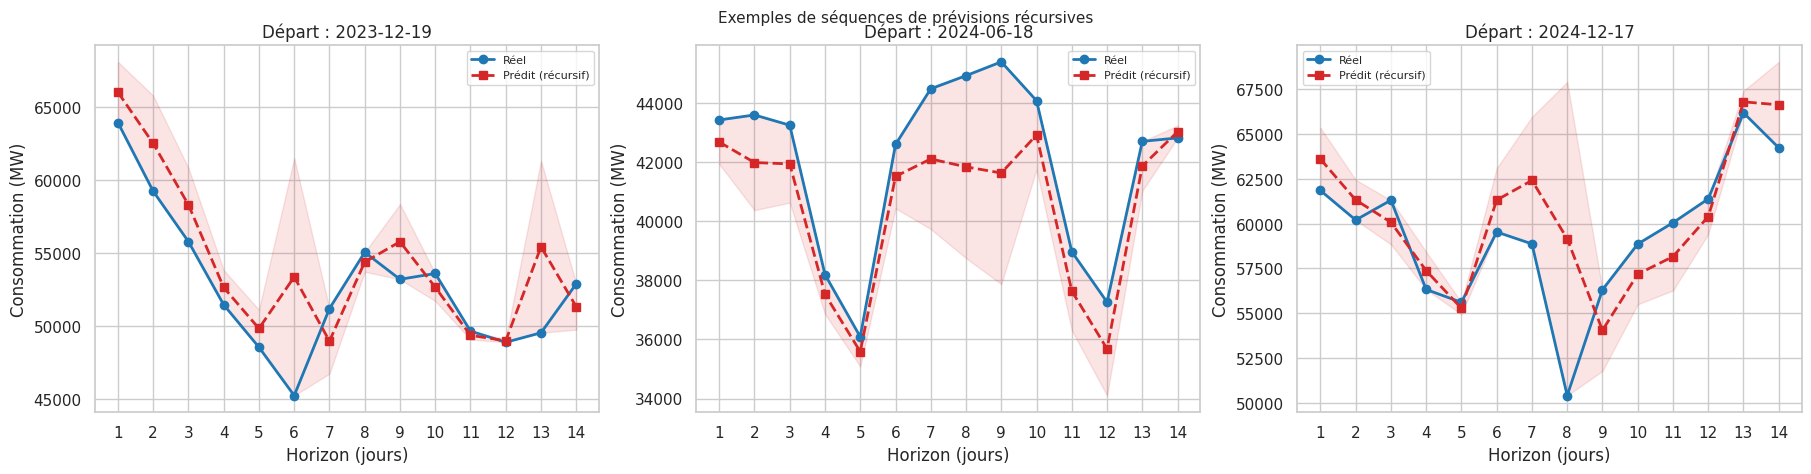

In [42]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# ── Métriques par horizon ─────────────────────────────────────────────────────
horizon_stats = []
for h in range(1, MAX_HORIZON + 1):
    sub = recursive_df[recursive_df["horizon"] == h]
    if len(sub) == 0:
        continue
    y_t = sub["actual"].values
    y_p = sub["predicted"].values
    horizon_stats.append({
        "h": h,
        "MAE (MW)": round(mean_absolute_error(y_t, y_p), 1),
        "RMSE (MW)": round(float(np.sqrt(mean_squared_error(y_t, y_p))), 1),
        "MAPE (%)": round(mean_absolute_percentage_error(y_t, y_p) * 100, 3),
        "n": len(sub),
    })

hm_df = pd.DataFrame(horizon_stats).set_index("h")
print("Métriques par horizon de prédiction récursive :")
display(hm_df)

# ── Courbes de dégradation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

for ax, col, color in zip(
    axes,
    ["MAE (MW)", "RMSE (MW)", "MAPE (%)"],
    ["#2ca02c", "#9467bd", "#d62728"],
):
    ax.plot(hm_df.index, hm_df[col], "o-", color=color, linewidth=2, markersize=6)
    ax.axhline(
        hm_df[col].iloc[0], color=color, linewidth=0.9, linestyle="--", alpha=0.45,
        label=f"t+1 baseline : {hm_df[col].iloc[0]:.1f}",
    )
    ax.set_title(f"Dégradation — {col}")
    ax.set_xlabel("Horizon (jours)")
    ax.set_ylabel(col)
    ax.set_xticks(range(1, MAX_HORIZON + 1))
    ax.legend(fontsize=8)

plt.suptitle(
    "Dégradation des performances selon l'horizon de prédiction récursive",
    fontsize=11, y=1.02,
)
plt.show()

# ── Distribution des erreurs par horizon (boxplot) ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
sns.boxplot(data=recursive_df, x="horizon", y="abs_error",
            ax=ax, color="#9ecae1", fliersize=2)
ax.set_title("Distribution des |erreurs| par horizon (prévisions récursives)")
ax.set_xlabel("Horizon (jours)")
ax.set_ylabel("|Erreur| (MW)")
plt.show()

# ── Exemples de trajectoires ──────────────────────────────────────────────────
sample_starts = sorted(recursive_df["start_date"].unique())
n_ex = min(3, len(sample_starts))
# Space examples across the evaluation window
indices = [0, len(sample_starts) // 2, len(sample_starts) - 1][:n_ex]
sample_starts = [sample_starts[i] for i in indices]

fig, axes = plt.subplots(1, n_ex, figsize=(6 * n_ex, 4.5), constrained_layout=True)
if n_ex == 1:
    axes = [axes]

for ax, start in zip(axes, sample_starts):
    sub = recursive_df[recursive_df["start_date"] == start].sort_values("horizon")
    ax.plot(sub["horizon"], sub["actual"], "o-", color="#1f77b4",
            linewidth=2, markersize=6, label="Réel")
    ax.plot(sub["horizon"], sub["predicted"], "s--", color="#d62728",
            linewidth=2, markersize=6, label="Prédit (récursif)")
    ax.fill_between(
        sub["horizon"],
        sub["predicted"] - sub["abs_error"],
        sub["predicted"] + sub["abs_error"],
        alpha=0.12, color="#d62728",
    )
    ax.set_title(f"Départ : {pd.Timestamp(start).date()}")
    ax.set_xlabel("Horizon (jours)")
    ax.set_ylabel("Consommation (MW)")
    ax.set_xticks(range(1, MAX_HORIZON + 1))
    ax.legend(fontsize=8)

plt.suptitle("Exemples de séquences de prévisions récursives",
             y=1.02, fontsize=11)
plt.show()

## 10. Analyse des résidus du modèle final

Les résidus du modèle SARIMAX correspondent aux erreurs de prédiction one-step-ahead. Un bon modèle doit produire des résidus proches d'un bruit blanc.


 Diagnostics résidus — Horizon t+1


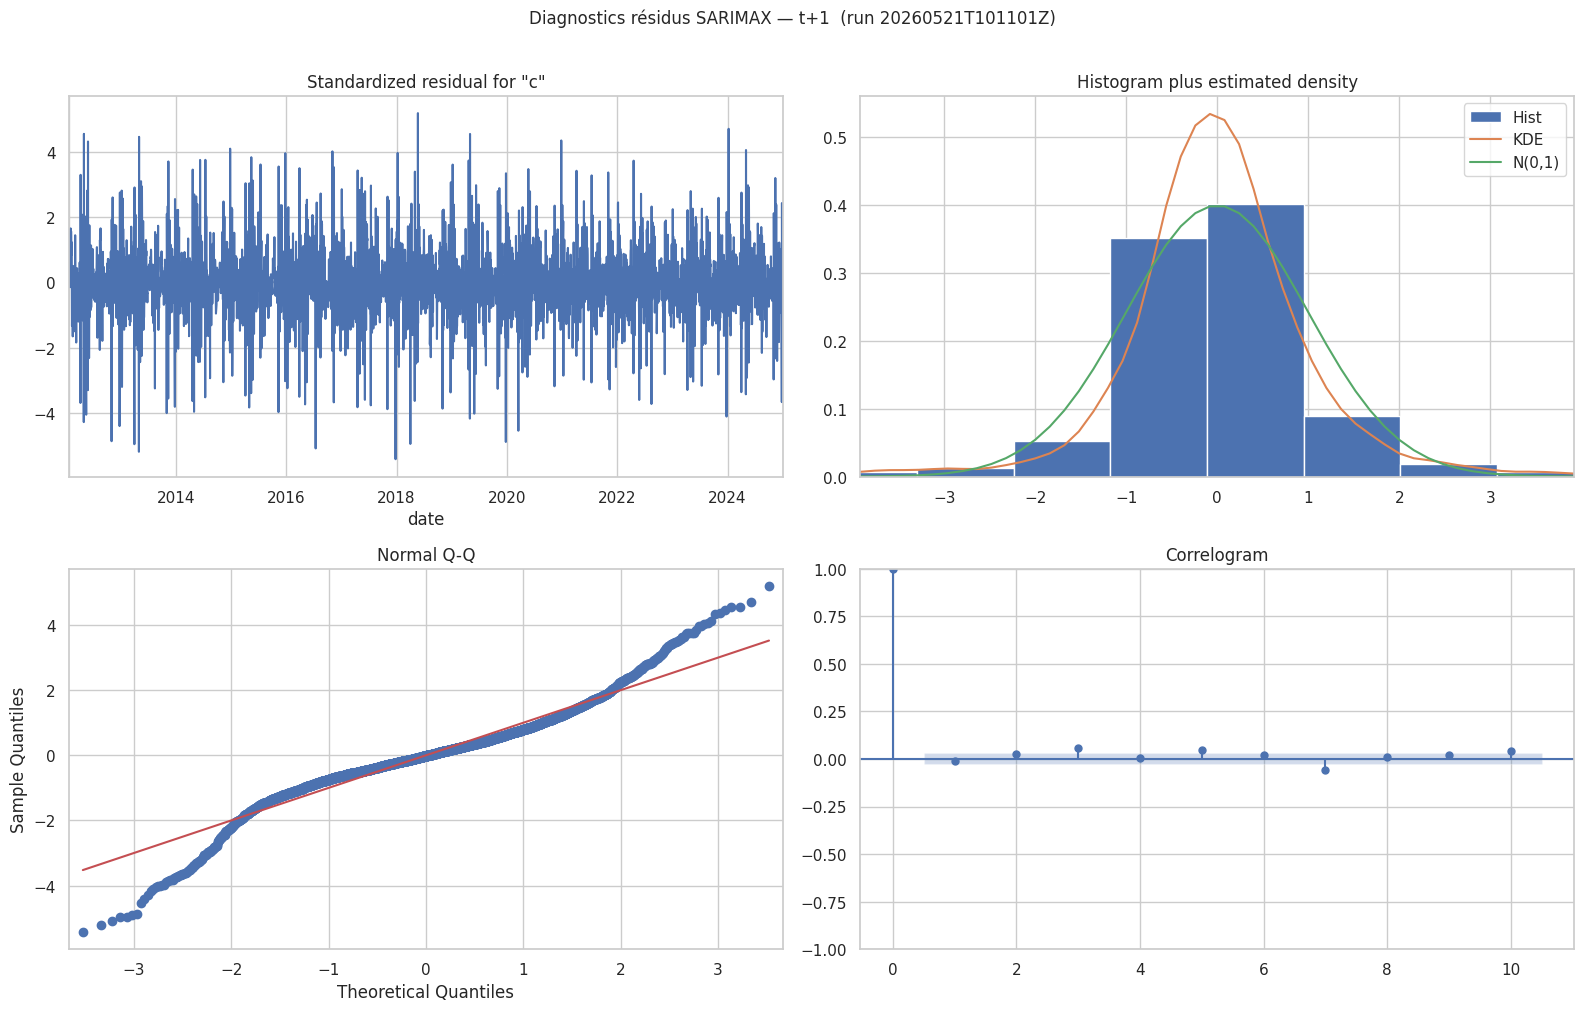

In [43]:
# Diagnostics statsmodels (Ljung-Box, normalité, Q-Q, correlogramme)
# Note : plot_diagnostics opère sur l'ensemble des résidus du modèle (méthode interne
# statsmodels). Les WARMUP_DAYS premiers jours ne peuvent pas être exclus ici ;
# les cellules suivantes (ACF/PACF, distribution) appliquent le filtre.
for h in HORIZONS:
    print(f"\n{'='*55}")
    print(f" Diagnostics résidus — Horizon t+{h}")
    print(f"{'='*55}")
    fig = models[h].plot_diagnostics(figsize=(16, 10))
    plt.suptitle(f"Diagnostics résidus SARIMAX — t+{h}  (run {run_id})",
                  y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()

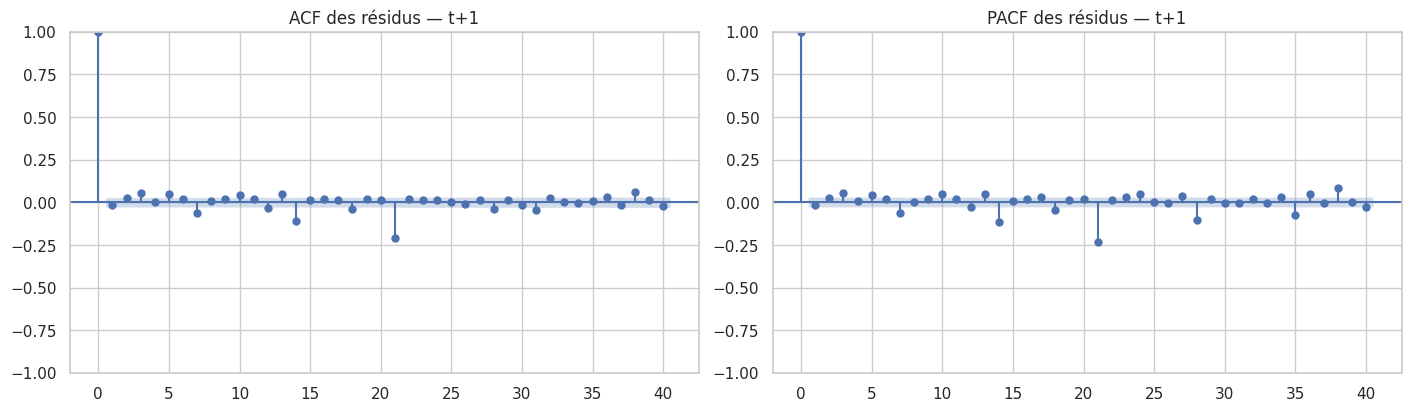

In [44]:
# ACF / PACF des résidus (WARMUP_DAYS premiers jours exclus)
for h in HORIZONS:
    resid = models[h].resid.dropna().iloc[WARMUP_DAYS:]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    plot_acf(resid, lags=40, ax=axes[0],
             title=f"ACF des résidus — t+{h}")
    plot_pacf(resid, lags=40, ax=axes[1], method="ywm",
              title=f"PACF des résidus — t+{h}")
    plt.show()

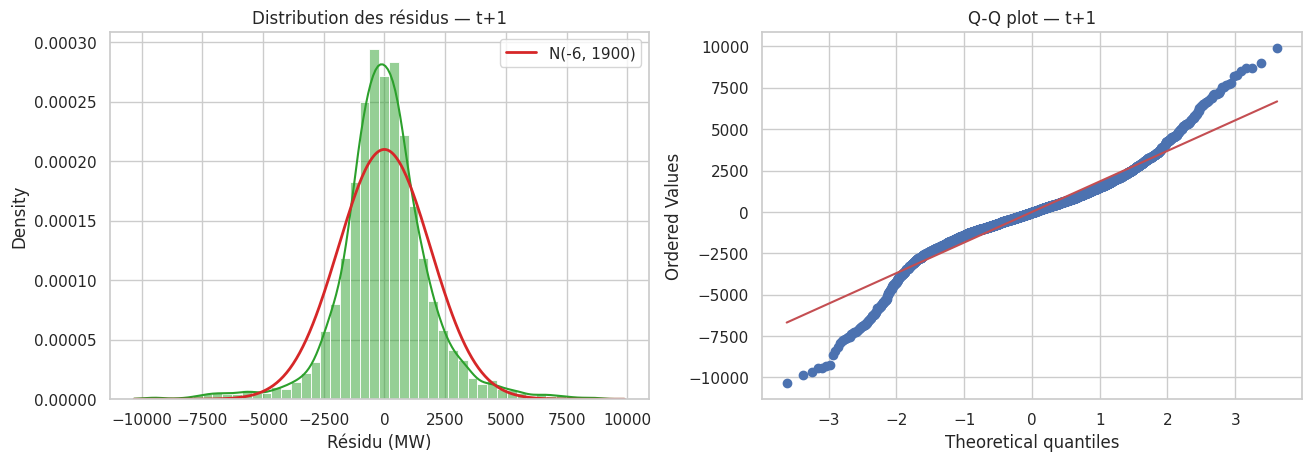


Résidus t+1 :
  Moyenne     : -5.6 MW
  Std (σ)     : 1899.8 MW
  Min / Max   : -10310 / 9879 MW
  Skewness    : -0.1399  (|s|>1 → asymétrie notable)
  Kurtosis    : 3.8256  (>3 → queues lourdes)
  Dans ±1σ    : 78.1%  (attendu ~68.3%)
  Dans ±2σ    : 94.4%  (attendu ~95.5%)


In [45]:
# Distribution des résidus + Q-Q plot + statistiques (WARMUP_DAYS premiers jours exclus)
for h in HORIZONS:
    resid = models[h].resid.dropna().iloc[WARMUP_DAYS:]
    mu, sigma = float(resid.mean()), float(resid.std())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

    # Histogramme + KDE + courbe normale théorique
    sns.histplot(resid, bins=50, kde=True, color="#2ca02c",
                 stat="density", ax=axes[0])
    x_range = np.linspace(resid.min(), resid.max(), 300)
    axes[0].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
                 color="#d62728", linewidth=2,
                 label=f"N({mu:.0f}, {sigma:.0f})")
    axes[0].set_title(f"Distribution des résidus — t+{h}")
    axes[0].set_xlabel("Résidu (MW)")
    axes[0].legend()

    # Q-Q plot
    stats.probplot(resid, dist="norm", plot=axes[1])
    axes[1].set_title(f"Q-Q plot — t+{h}")

    plt.show()

    # Statistiques descriptives
    pct_1s = float((resid.abs() <= sigma).mean() * 100)
    pct_2s = float((resid.abs() <= 2 * sigma).mean() * 100)
    print(f"\nRésidus t+{h} :")
    print(f"  Moyenne     : {mu:+.1f} MW")
    print(f"  Std (σ)     : {sigma:.1f} MW")
    print(f"  Min / Max   : {resid.min():.0f} / {resid.max():.0f} MW")
    print(f"  Skewness    : {resid.skew():.4f}  (|s|>1 → asymétrie notable)")
    print(f"  Kurtosis    : {resid.kurtosis():.4f}  (>3 → queues lourdes)")
    print(f"  Dans ±1σ    : {pct_1s:.1f}%  (attendu ~68.3%)")
    print(f"  Dans ±2σ    : {pct_2s:.1f}%  (attendu ~95.5%)")

## 11. Seuils de monitoring et synthèse

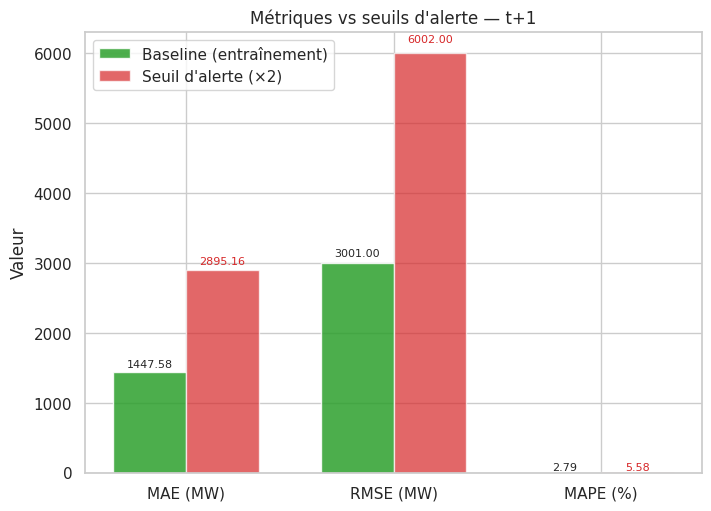


 Synthèse — Run 20260521T101101Z


,MAE (MW),RMSE (MW),MAPE (%),σ résidus (MW),>2σ (%),Skewness,AIC,Santé résidus
Horizon,,,,,,,,
t+1,1447.58,3001.0,2.7891,1899.8,5.6,-0.14,84768.89,⚠ kurtosis=3.83


In [46]:
METRIC_KEYS = [
    ("insample_MAE_MW", "MAE (MW)"),
    ("insample_RMSE_MW", "RMSE (MW)"),
    ("insample_MAPE_pct", "MAPE (%)"),
]

fig, axes = plt.subplots(1, len(HORIZONS),
                          figsize=(7 * len(HORIZONS), 5),
                          constrained_layout=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, h in zip(axes, HORIZONS):
    m = meta_by_h[h].get("insample_metrics", {})
    labels, baselines, alerts = [], [], []
    for key, label in METRIC_KEYS:
        v = m.get(key)
        if v is not None:
            labels.append(label)
            baselines.append(v)
            alerts.append(v * _ALERT_FACTOR)

    x = np.arange(len(labels))
    w = 0.35
    bars_b = ax.bar(x - w / 2, baselines, w,
                    label="Baseline (entraînement)", color="#2ca02c", alpha=0.85)
    bars_a = ax.bar(x + w / 2, alerts, w,
                    label=f"Seuil d'alerte (×{_ALERT_FACTOR:.0f})", color="#d62728", alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f"Métriques vs seuils d'alerte — t+{h}")
    ax.set_ylabel("Valeur")
    ax.legend()

    for i, (b, a) in enumerate(zip(baselines, alerts)):
        ax.text(i - w / 2, b * 1.02, f"{b:.2f}", ha="center", va="bottom", fontsize=8)
        ax.text(i + w / 2, a * 1.02, f"{a:.2f}", ha="center", va="bottom",
                fontsize=8, color="#d62728")

plt.show()

# Tableau de synthèse final (WARMUP_DAYS premiers jours exclus)
synth_rows = []
for h in HORIZONS:
    resid = models[h].resid.dropna().iloc[WARMUP_DAYS:]
    m = meta_by_h[h].get("insample_metrics", {})
    gof = meta_by_h[h].get("goodness_of_fit", {})
    sigma = float(resid.std())
    pct_out = float((resid.abs() > 2 * sigma).mean() * 100)

    issues = []
    if abs(float(resid.skew())) > 1.0:
        issues.append(f"skewness={resid.skew():.2f}")
    if float(resid.kurtosis()) > 3.0:
        issues.append(f"kurtosis={resid.kurtosis():.2f}")
    if pct_out > 10.0:
        issues.append(f"{pct_out:.1f}% hors ±2σ")
    health = "⚠ " + ", ".join(issues) if issues else "✓ OK"

    synth_rows.append({
        "Horizon": f"t+{h}",
        "MAE (MW)": m.get("insample_MAE_MW"),
        "RMSE (MW)": m.get("insample_RMSE_MW"),
        "MAPE (%)": m.get("insample_MAPE_pct"),
        "σ résidus (MW)": round(sigma, 1),
        ">2σ (%)": round(pct_out, 1),
        "Skewness": round(float(resid.skew()), 3),
        "AIC": gof.get("aic"),
        "Santé résidus": health,
    })

synth_df = pd.DataFrame(synth_rows).set_index("Horizon")
print(f"\n{'='*55}")
print(f" Synthèse — Run {run_id}")
print(f"{'='*55}")
display(synth_df)